<a href="https://colab.research.google.com/github/phmlehau/TH_DeepLearning/blob/main/Lap2_TH_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
from scikeras.wrappers import KerasClassifier
from keras.layers import Dropout
from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler

In [4]:
!pip install scikeras

In [6]:
fashion = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion.load_data()
print(X_train.shape, y_train.shape,X_test.shape,y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [7]:
X_train = X_train.reshape(60000,784)
X_test = X_test.reshape(10000,784)
minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)
print('Number of classes:',len(np.unique(y_train)))
print('Classes:',np.unique(y_train))

Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


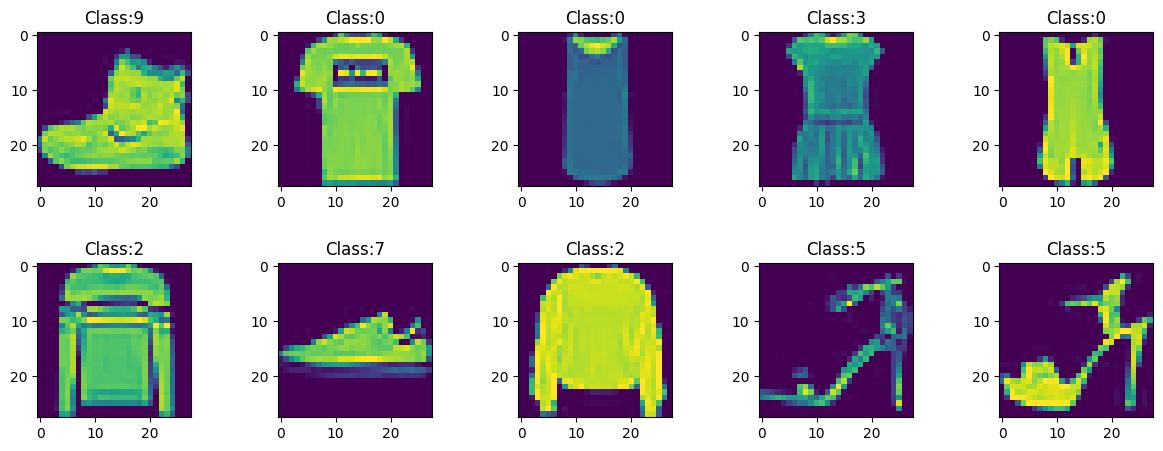

In [8]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15,5))
ax = axes.flatten()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28,28))
    ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

3.5. Xây dựng mô hình học ANN

In [10]:
fashion_model = Sequential()
fashion_model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform',activation='relu'))
fashion_model.add(Dense(units=10, kernel_initializer='uniform',activation='softmax'))
fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
fashion_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model_fit = fashion_model.fit(X_train, y_train, validation_split=0.1, epochs=20, verbose=1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8206 - loss: 0.5063 - val_accuracy: 0.8610 - val_loss: 0.3900
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8651 - loss: 0.3700 - val_accuracy: 0.8625 - val_loss: 0.3858
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8785 - loss: 0.3302 - val_accuracy: 0.8782 - val_loss: 0.3437
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8868 - loss: 0.3070 - val_accuracy: 0.8738 - val_loss: 0.3530
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8951 - loss: 0.2865 - val_accuracy: 0.8800 - val_loss: 0.3404
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.8993 - loss: 0.2705 - val_accuracy: 0.8825 - val_loss: 0.3244
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.9045 - loss: 0.2573 - val_accuracy: 0.8845 - val_loss: 0.3289
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9060 - loss: 0.

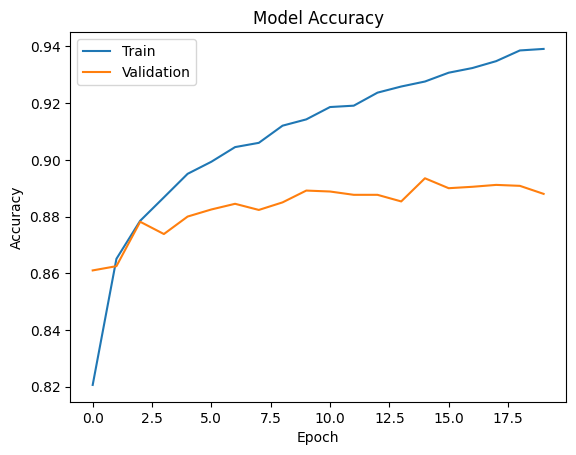

In [12]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

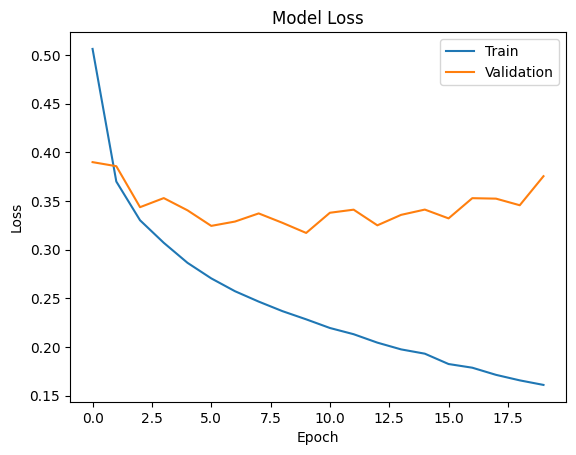

In [13]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

In [14]:
print(np.argmax(fashion_model.predict(X_test)[0]),y_test[0])
print(np.argmax(fashion_model.predict(X_test)[10]),y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
4 4


In [15]:
mnist_train_path='/content/sample_data/patient_heart_rate.csv'
mnist_test_path='/content/sample_data/heart_disease_dataset.csv'
mnist_train = pd.read_csv(mnist_train_path)
mnist_test = pd.read_csv(mnist_test_path)
print(mnist_train.head,mnist_train.shape)

<bound method NDFrame.head of        1    Mickéy Mousé    56       70kgs   72   69   71    -  -.1  -.2
0    2.0     Donald Duck  34.0   154.89lbs    -    -    -   85   84   76
1    3.0      Mini Mouse  16.0         NaN    -    -    -   65   69   72
2    4.0  Scrooge McDuck   NaN       78kgs   78   79   72    -    -    -
3    5.0    Pink Panther  54.0  198.658lbs    -    -    -   69  NaN   75
4    6.0     Huey McDuck  52.0      189lbs    -    -    -   68   75   72
5    7.0    Dewey McDuck  19.0       56kgs    -    -    -   71   78   75
6    8.0      Scööpy Doo  32.0       78kgs   78   76   75    -    -    -
7    NaN             NaN   NaN         NaN  NaN  NaN  NaN  NaN  NaN  NaN
8    NaN             NaN   NaN         NaN  NaN  NaN  NaN  NaN  NaN  NaN
9    9.0     Huey McDuck  52.0      189lbs    -    -    -   68   75   72
10  10.0    Louie McDuck  12.0       45kgs    -    -    -   92   95   87
11  11.0       Henry Nam   NaN       60kgs   78   75   72    -    -    -
12  12.0     Michel L

In [32]:
# Assuming heart_disease_dataset.csv (mnist_test) is the dataset to use for training and testing
# Load the data and identify features (X) and target (y)
data = mnist_test.copy() # Start fresh with the heart disease dataset

# Separate features and target
# 'state' is the target column in heart_disease_dataset.csv
X_raw = data.drop(columns=['state'])
y = data['state']

# Drop rows with NaN values in the target variable
# This ensures X and y have matching cardinality
non_nan_indices = y.dropna().index
X_cleaned = X_raw.loc[non_nan_indices].copy()
y_cleaned = y.loc[non_nan_indices].copy()

# For this scenario, we will use the cleaned data as both training and testing sets
# In a real-world scenario, a proper train-test split would be performed here.
X_train = X_cleaned
y_train = y_cleaned
X_test = X_cleaned.copy() # Ensure X_test is a separate copy to avoid modification by reference
y_test = y_cleaned.copy()

print(X_train.shape)
print('Number of classes:',len(np.unique(y_train)))
print('Classes:',np.unique(y_train))

(293, 13)
Number of classes: 5
Classes: [0. 1. 2. 3. 4.]


In [40]:
# Identify categorical columns to be one-hot encoded
categorical_cols = ['sex', 'cp', 'thal', 'fbs']

# Ensure categorical columns are of string type to prevent potential issues with pd.get_dummies
# and avoid potential mixed types if data loading was imperfect.
for col in categorical_cols:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype(str)
    if col in X_test.columns:
        X_test[col] = X_test[col].astype(str)

# Combine X_train and X_test for consistent one-hot encoding
combined_data = pd.concat([X_train, X_test], ignore_index=True)

# Apply one-hot encoding to the combined dataset, but only to existing categorical columns
cols_to_encode = [col for col in categorical_cols if col in combined_data.columns]
combined_data_encoded = pd.get_dummies(combined_data, columns=cols_to_encode, drop_first=True)

# Split back into X_train and X_test
X_train_encoded = combined_data_encoded.iloc[:len(X_train)]
X_test_encoded = combined_data_encoded.iloc[len(X_train):]

# Update X_train and X_test with the encoded versions
X_train = X_train_encoded
X_test = X_test_encoded

# Handle potential NaN values that might still exist in numerical columns after one-hot encoding
# For simplicity, we'll fill them with the mean of their respective columns.
# In a real scenario, more sophisticated imputation methods might be considered.
X_train = X_train.fillna(X_train.mean(numeric_only=True))
X_test = X_test.fillna(X_test.mean(numeric_only=True))

print(X_train.head())
print(X_train.shape)

    age  trestbps   chol  restecg  thalach  exang  oldpeak  slope   ca  sex_M  \
0  63.0     145.0  233.0      2.0    150.0    0.0      2.3    3.0  0.0   True   
1  67.0     160.0  286.0      2.0    108.0    1.0      1.5    2.0  3.0   True   
2  67.0     120.0  229.0      2.0    129.0    1.0      2.6    2.0  2.0   True   
3  37.0     130.0  250.0      0.0    187.0    0.0      3.5    3.0  0.0   True   
4  41.0     130.0  204.0      2.0    172.0    0.0      1.4    1.0  0.0  False   

   cp_asp  cp_nap  cp_tap  thal_3.0  thal_6.0  thal_7.0  fbs_yes  
0   False   False    True     False      True     False     True  
1    True   False   False      True     False     False    False  
2    True   False   False     False     False      True    False  
3   False    True   False      True     False     False    False  
4   False   False   False      True     False     False    False  
(293, 17)


In [35]:
import tensorflow as tf
import keras
from keras import Sequential
from keras.layers import Dense

In [36]:
num_classes = len(np.unique(y_train))
model = Sequential()
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform',activation='relu'))
model.add(Dense(units=num_classes, kernel_initializer='uniform',activation='softmax')) # Adjusted units to match actual classes
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,893 (23.02 KB)

 Trainable params: 5,893 (23.02 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model_fit = model.fit(X_train, y_train,epochs=30, verbose=1)

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4505 - loss: 1.7318  
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4437 - loss: 1.4369 
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5461 - loss: 1.2193 
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5358 - loss: 1.2350 
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5495 - loss: 1.2354 
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5427 - loss: 1.2433 
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5836 - loss: 1.1891 
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5563 - loss: 1.1718 
Epoch 9/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5597 - loss: 1.1489 
Epoch 10/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5666 - loss: 1.1482 
Epoch 11/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5973 - loss: 1.0952 
Epoch 12/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy:

In [42]:
print(np.argmax(model.predict(X_test)[0]),y_test[0])

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
0 0.0


In [44]:
img_size = (28, 28)
img = tf.keras.preprocessing.image.load_img(
'/content/sample_data/jerry2.jpg', color_mode='grayscale', target_size=img_size)
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.squeeze(img_array)
img = np.reshape(img_array, (784))
img_array = tf.expand_dims (img,0)
img_array = tf.convert_to_tensor(img_array)

img_array = img_array / 255.0

print(img_array.shape)
img_predict = fashion_model.predict(img_array)
print(img_predict)
score = np.argmax(img_predict)
print(score)

(1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
[[1.1212892e-15 4.1188881e-25 5.4886842e-18 5.3225324e-19 2.9770964e-18
  9.2849338e-16 8.3707405e-19 1.7295314e-17 1.0000000e+00 1.6157991e-19]]
8


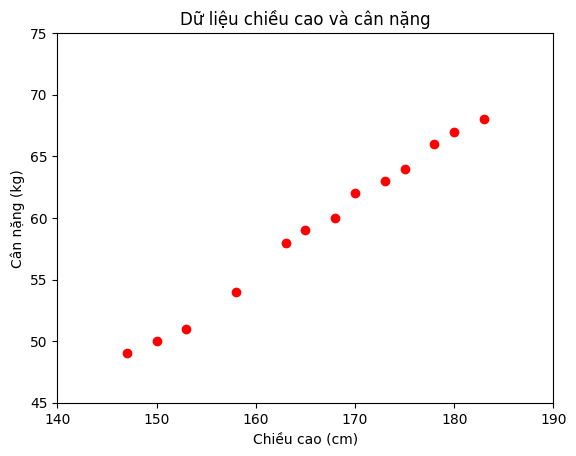

Vector trọng số w (tính bằng công thức):  [[-33.73541021   0.55920496]]
Hệ số bias w_0 = -33.74
Hệ số góc w_1 = 0.56


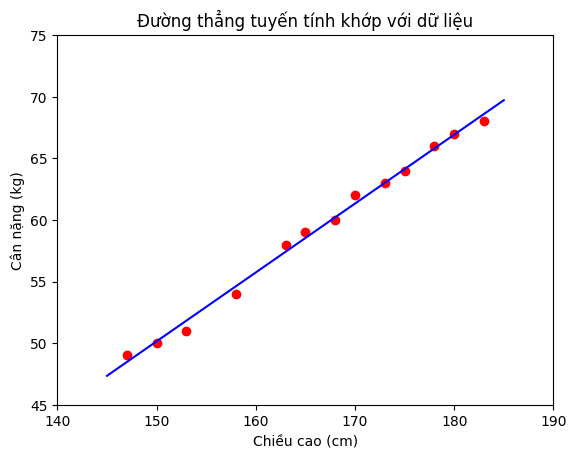

Dự đoán cân nặng người cao 155 cm: 52.94 (kg)
Dự đoán cân nặng người cao 160 cm: 55.74 (kg)

Nghiệm tìm được bởi scikit-learn  :  [[-33.73541021   0.55920496]]
Nghiệm tìm được bằng công thức (5):  [[-33.73541021   0.55920496]]


In [45]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, linear_model


X = np.array([[147, 150, 153, 158, 163, 165, 168, 170, 173, 175, 178, 180, 183]]).T


y = np.array([[ 49, 50, 51,  54, 58, 59, 60, 62, 63, 64, 66, 67, 68]]).T


plt.plot(X, y, 'ro')
plt.axis([140, 190, 45, 75])
plt.xlabel('Chiều cao (cm)')
plt.ylabel('Cân nặng (kg)')
plt.title('Dữ liệu chiều cao và cân nặng')
plt.show()


one = np.ones((X.shape[0], 1))
Xbar = np.concatenate((one, X), axis = 1)


A = np.dot(Xbar.T, Xbar)
b = np.dot(Xbar.T, y)


w = np.dot(np.linalg.pinv(A), b)
print('Vector trọng số w (tính bằng công thức): ', w.T)


w_0 = w[0][0]
w_1 = w[1][0]
print(f'Hệ số bias w_0 = {w_0:.2f}')
print(f'Hệ số góc w_1 = {w_1:.2f}')

x0 = np.linspace(145, 185, 2)
y0 = w_0 + w_1 * x0

plt.plot(X, y, 'ro')
plt.plot(x0, y0, 'b')
plt.axis([140, 190, 45, 75])
plt.xlabel('Chiều cao (cm)')
plt.ylabel('Cân nặng (kg)')
plt.title('Đường thẳng tuyến tính khớp với dữ liệu')
plt.show()

y1 = w_1 * 155 + w_0
y2 = w_1 * 160 + w_0

print(f'Dự đoán cân nặng người cao 155 cm: {y1:.2f} (kg)')
print(f'Dự đoán cân nặng người cao 160 cm: {y2:.2f} (kg)')

regr = linear_model.LinearRegression(fit_intercept=False)
regr.fit(Xbar, y)

print('\nNghiệm tìm được bởi scikit-learn  : ', regr.coef_ )
print('Nghiệm tìm được bằng công thức (5): ', w.T)